In [1]:
import pandas as pd
import numpy as np
import os
import json
import gensim.downloader as downloader
import matplotlib.pyplot as plt
from keras.preprocessing.text import text_to_word_sequence
from nltk import word_tokenize
from sklearn.model_selection import train_test_split

/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def get_list_dicts(file):
    return [json.loads(line) for line in open(file, "rt")]

raw_data = get_list_dicts("/Users/rutvikdhopate/Downloads/Magazine_Subscriptions.jsonl")

In [24]:
df = pd.DataFrame(raw_data).loc[:,['user_id','asin','rating','text']]
df['text'] = df['text'].astype(str)
df['text'] = df['text'].apply(lambda x: ' '.join(text_to_word_sequence(x)))
df = df[df['text'].str.len() > 1]
df.drop_duplicates(subset=['user_id','asin'], inplace=True)
df.dropna(inplace=True)

In [34]:
# Idea is to group the reviews based on the users and the items as inputs for 2 parallel Neural Nets
grouped_u = df.groupby('user_id').agg(
    text=('text', ' <SEP> '.join),  # Concatenate reviews for each user
    rating=('rating', 'first')     # Calculate the average rating for each user
).reset_index()
grouped_i = df.groupby('asin').agg(
    text=('text', ' <SEP> '.join),  # Concatenate reviews for each item
    rating=('rating', 'first')     # Calculate the average rating for each item
).reset_index()

In [35]:
grouped_u

,user_id,text,rating
0,AE222ELC2EMGPS4KSGXKMSFZTOYA,this is awesome for any reading child my 7 yr ...,5.0
1,AE22GENSIU4K5QR7RYJLRTZKCR2A,i have gotten every other magazine that i subs...,1.0
2,AE22HJCBUA3OCUGL7LW4YHHANUWQ,purchased for my sisters birthday and she love...,5.0
3,AE22J4D76YM6ZBBRSUKCIK5BRJLQ,gave my grandson subscription i take every opp...,5.0
4,AE22KFYQBL52KJR5BWDLFR4IZF4A,i had ordered marie claire with amazon on 11 0...,1.0
...,...,...,...
60067,AHZZ7GPN63TEIWPH3ZLZAJL2BYZQ,fascinating reading material,5.0
60068,AHZZHZWI5HAOFSD3BX6C3YP3DBSQ,i love this magazine i was buying it at the ne...,5.0
60069,AHZZN3RBWHMF3T6ED7DUWGDSK7BQ,it is helpful to see what styles are in style ...,5.0
60070,AHZZOVULYZC5L7SFEZXTKIS5CUZQ,granddaughter loves this magazine keeps her up...,5.0


In [32]:
# Idea is to group the reviews based on the users and the items as inputs for 2 parallel Neural Nets
# grouped_u = df.groupby('user_id')['text'].apply(' <SEP> '.join).reset_index()
# grouped_i = df.groupby('asin')['text'].apply(' <SEP> '.join).reset_index()

In [5]:
# Number of Unique Users and Unique Items in the dataset
print(f"Unique Users: {grouped_u.shape[0]}, Unique Items: {grouped_i.shape[0]}")

Unique Users: 60072, Unique Items: 3390


/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:6890: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


([<matplotlib.axis.XTick at 0x305b62760>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20+')])

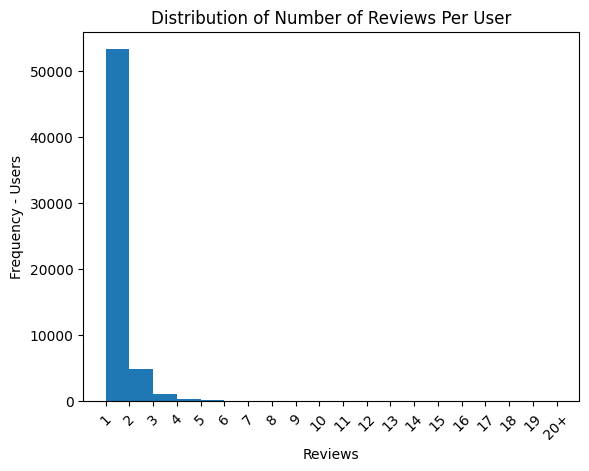

In [6]:
# Distribution of Number of Reviews given by a user
bins = list(range(1, 21, 1)) + [float('inf')]  # Creates bins [0-20, 20-40, ..., 180-200, 200+]
plt.hist(list(df.groupby('user_id').aggregate({'asin':'count'})['asin']), bins=bins)
plt.xlabel('Reviews')
plt.ylabel('Frequency - Users')
plt.title('Distribution of Number of Reviews Per User')
plt.xticks(bins[:-1], labels=[f"{bins[i]}" if bins[i+1] != float('inf') else f"{bins[i]}+" for i in range(len(bins)-1)], rotation=45)


/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:6890: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


([<matplotlib.axis.XTick at 0x306a54310>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20+')])

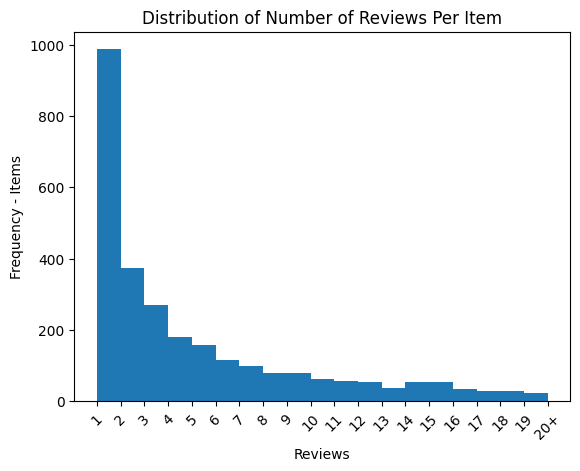

In [7]:
bins = list(range(1, 21, 1)) + [float('inf')] 
plt.hist(list(df.groupby('asin').aggregate({'user_id':'count'})['user_id']), bins=bins)
plt.xlabel('Reviews')
plt.ylabel('Frequency - Items')
plt.title('Distribution of Number of Reviews Per Item')
plt.xticks(bins[:-1], labels=[f"{bins[i]}" if bins[i+1] != float('inf') else f"{bins[i]}+" for i in range(len(bins)-1)], rotation=45)


/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:6890: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


([<matplotlib.axis.XTick at 0x306b698b0>,
 [Text(0, 0, '0-19'),
  Text(20, 0, '20-39'),
  Text(40, 0, '40-59'),
  Text(60, 0, '60-79'),
  Text(80, 0, '80-99'),
  Text(100, 0, '100-119'),
  Text(120, 0, '120-139'),
  Text(140, 0, '140-159'),
  Text(160, 0, '160-179'),
  Text(180, 0, '180-199'),
  Text(200, 0, '200+')])

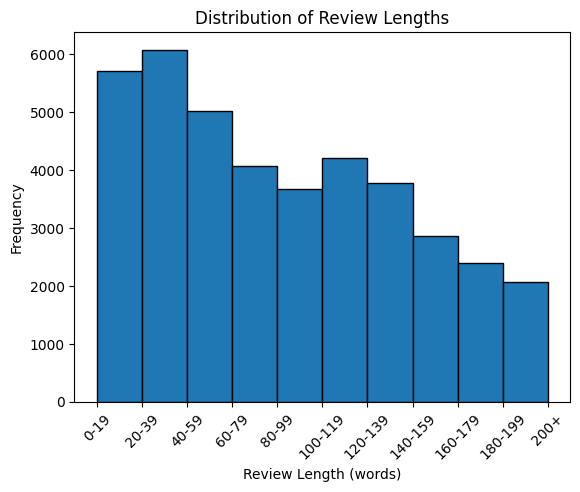

In [8]:
# Review Lengths After Concatenation per User
bins = list(range(0, 201, 20)) + [float('inf')]  # Creates bins [0-20, 20-40, ..., 180-200, 200+]

plt.hist(grouped_u['text'].apply(len), bins=bins, edgecolor='black')
plt.xlabel('Review Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.xticks(bins[:-1], labels=[f"{bins[i]}-{bins[i+1]-1}" if bins[i+1] != float('inf') else f"{bins[i]}+" for i in range(len(bins)-1)], rotation=45)


/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_axes.py:6890: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


([<matplotlib.axis.XTick at 0x306bc48e0>,
 [Text(0, 0, '0-19'),
  Text(20, 0, '20-39'),
  Text(40, 0, '40-59'),
  Text(60, 0, '60-79'),
  Text(80, 0, '80-99'),
  Text(100, 0, '100-119'),
  Text(120, 0, '120-139'),
  Text(140, 0, '140-159'),
  Text(160, 0, '160-179'),
  Text(180, 0, '180-199'),
  Text(200, 0, '200-219'),
  Text(220, 0, '220-239'),
  Text(240, 0, '240-259'),
  Text(260, 0, '260-279'),
  Text(280, 0, '280-299'),
  Text(300, 0, '300-319'),
  Text(320, 0, '320-339'),
  Text(340, 0, '340-359'),
  Text(360, 0, '360-379'),
  Text(380, 0, '380-399'),
  Text(400, 0, '400-419'),
  Text(420, 0, '420-439'),
  Text(440, 0, '440-459'),
  Text(460, 0, '460-479'),
  Text(480, 0, '480-499'),
  Text(500, 0, '500-519'),
  Text(520, 0, '520-539'),
  Text(540, 0, '540-559'),
  Text(560, 0, '560-579'),
  Text(580, 0, '580-599'),
  Text(600, 0, '600-619'),
  Text(620, 0, '620-639'),
  Text(640, 0, '640-659'),
  Text(660, 0, '660-679'),
  Text(680, 0, '680-699'),
  Text(700, 0, '700-719'),
  T

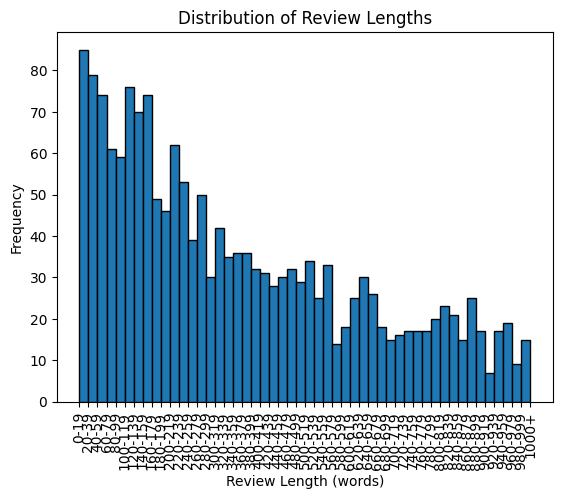

In [9]:
# Review Lengths After Concatenation per Item
bins = list(range(0, 1001, 20)) + [float('inf')]

plt.hist(grouped_i['text'].apply(len), bins=bins, edgecolor='black')
plt.xlabel('Review Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.xticks(bins[:-1], labels=[f"{bins[i]}-{bins[i+1]-1}" if bins[i+1] != float('inf') else f"{bins[i]}+" for i in range(len(bins)-1)], rotation=90)


In [10]:
embeds = downloader.load('word2vec-google-news-300')

In [11]:
# Add 3 new tokens to the embeds dictionary
'''
    <UNK> - Representation for the word that is not a part of the pretrained embeddings
    <SEP> - The reviews are concatenated by a token to indicate that there's a separation
    <PAD> - 300 zeros to match the length of the sentence. 
'''

embeds['<UNK>'] = np.random.randn(300).astype(np.float32)
embeds['<SEP>'] = np.random.randn(300).astype(np.float32)
embeds['<PAD>'] = np.zeros(300, dtype=np.float32)

In [12]:
# Convert the sentences to tokens
grouped_i['text'] = grouped_i['text'].apply(lambda x: word_tokenize(x))
grouped_u['text'] = grouped_u['text'].apply(lambda x: word_tokenize(x))

In [14]:
def create_embeddings(review_text, max_length, embedding_dict):
    if len(review_text) > max_length:
        review_text = review_text[:max_length]
    else:
        review_text = review_text + (max_length-len(review_text))*['<PAD>']
    
    # Now that the length is unique, map the words from the embedding_dict
    text_embeddings = np.array([embedding_dict[token] if token in embedding_dict else embedding_dict['<PAD>'] for token in review_text])
    return text_embeddings
    

In [124]:
# Create the Embeddings with max_length of 200 words for concatenated user reviews and 1000 words for concatenated item reviews
grouped_u['text_embeddings'] = grouped_u['text'].apply(lambda x: create_embeddings(x, max_length=200, embedding_dict=embeds))
grouped_i['text_embeddings'] = grouped_i['text'].apply(lambda x: create_embeddings(x, max_length=1000, embedding_dict=embeds))

: 

In [15]:
grouped_u['text_embeddings'] = grouped_u['text'].apply(lambda x: create_embeddings(x, max_length=200, embedding_dict=embeds))

In [20]:
# Need to Encode the user_id and asin as well

user_id_encoding = {user: idx for idx, user in enumerate(grouped_u['user_id'])}
asin_encoding = {item: idx for idx, item in enumerate(grouped_i['asin'])}

(200, 300)

In [ ]:
# Create the embeddings with the predefined review length (user=200) and 

In [123]:
# # Replace the tokens with the embeddings
# grouped_u['text'] = grouped_u['text'].apply(lambda x: [embeds[token] if token in embeds else np.zeros(300) for token in x])
# grouped_i['text'] = grouped_i['text'].apply(lambda x: [embeds[token] if token in embeds else np.zeros(300) for token in x])


In [1]:
import pandas as pd
import numpy as np
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import gensim.downloader as downloader
import nltk
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from nltk import word_tokenize
# from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

def get_list_dicts(file):
    return [json.loads(line) for line in open(file, "rt")]

raw_data = get_list_dicts("/Users/rutvikdhopate/Downloads/Magazine_Subscriptions.jsonl")
# raw_data = get_list_dicts("Magazine_Subscriptions.jsonl")
df = pd.DataFrame(raw_data).loc[:,['user_id','asin','rating','text']]
df = df.iloc[:500,:]
# print(df.shape)
df['text'] = df['text'].astype(str)
df['text'] = df['text'].apply(lambda x: ' '.join(text_to_word_sequence(x)))
df = df[df['text'].str.len() > 1]
df.drop_duplicates(subset=['user_id','asin'], inplace=True)
df.dropna(inplace=True)
# print(df.shape)
# print(df.head())

# Idea is to group the reviews based on the users and the items as inputs for 2 parallel Neural Nets
# grouped_u = df.groupby('user_id')['text'].apply(' <SEP> '.join).reset_index()
# grouped_i = df.groupby('asin')['text'].apply(' <SEP> '.join).reset_index()

grouped_u = df.groupby('user_id').agg(
    text=('text', ' <SEP> '.join),  # Concatenate reviews for each user
    rating=('rating', 'mean')     # Calculate the average rating for each user
).reset_index()
grouped_i = df.groupby('asin').agg(
    text=('text', ' <SEP> '.join),  # Concatenate reviews for each item
    rating=('rating', 'mean')     # Calculate the average rating for each item
).reset_index()

# Number of Unique Users and Unique Items in the dataset
print(f"Unique Users: {grouped_u.shape[0]}, Unique Items: {grouped_i.shape[0]}")

# Google Word-2-vec word embeddings - as mentioned in the paper
embeds = downloader.load('word2vec-google-news-300')

# Add 3 new tokens to the embeds dictionary
'''
    <UNK> - Representation for the word that is not a part of the pretrained embeddings
    <SEP> - The reviews are concatenated by a token to indicate that there's a separation
    <PAD> - 300 zeros to match the length of the sentence. 
'''

embeds['<UNK>'] = np.random.randn(300).astype(np.float32)
embeds['<SEP>'] = np.random.randn(300).astype(np.float32)
embeds['<PAD>'] = np.zeros(300, dtype=np.float32)

# Convert the sentences to tokens
nltk.download('punkt_tab')
grouped_u['text'] = grouped_u['text'].apply(lambda x: word_tokenize(x))
grouped_i['text'] = grouped_i['text'].apply(lambda x: word_tokenize(x))


# Represent the words as a fixed length; thus PAD or TRIM the tokens respectively
def create_embeddings(review_text, max_length, embedding_dict):
    if len(review_text) > max_length:
        review_text = review_text[:max_length]
    else:
        review_text = review_text + (max_length-len(review_text))*['<PAD>']
    
    # Now that the length is unique, map the words from the embedding_dict
    text_embeddings = np.array([embedding_dict[token] if token in embedding_dict else embedding_dict['<PAD>'] for token in review_text])
    return text_embeddings
    

# Create the Embeddings with max_length of 200 words for concatenated user reviews and 1000 words for concatenated item reviews
grouped_u['text_embeddings'] = grouped_u['text'].apply(lambda x: create_embeddings(x, max_length=200, embedding_dict=embeds))
grouped_i['text_embeddings'] = grouped_i['text'].apply(lambda x: create_embeddings(x, max_length=200, embedding_dict=embeds))

print("Checkpoint - Embeddings")
# Need to Encode the user_id and asin as well
# user_id_encoding = {user: idx for idx, user in enumerate(grouped_u['user_id'])}
# asin_encoding = {item: idx for idx, item in enumerate(grouped_i['asin'])}


# # Data Splitting - 80% train, 10% val, 10% test
# train_u, test_u = train_test_split(grouped_u, test_size=0.2, random_state=42)
# valid_u, test_u = train_test_split(test_u, test_size=0.5, random_state=42)

# # Split the grouped_i (item reviews) into train, validation, and test sets
# train_i, test_i = train_test_split(grouped_i, test_size=0.2, random_state=42)
# valid_i, test_i = train_test_split(test_i, test_size=0.5, random_state=42)

user_x = torch.tensor(np.stack(grouped_u['text_embeddings'].values), dtype=torch.float)
user_y = torch.tensor(grouped_u['rating'], dtype=torch.float)
item_x = torch.tensor(np.stack(grouped_i['text_embeddings'].values), dtype=torch.float)
item_y = torch.tensor(grouped_i['rating'], dtype=torch.float)


# Preparing the embedding weight tensor
embedding_dim = embeds.vector_size
vocab_size = len(embeds.key_to_index)

wtoi = {word: idx for idx, word in enumerate(embeds.key_to_index.keys())}
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill the matrix with pre trained embeddings
for word, idx in wtoi.items():
    try:
        # Try to get the vector for the word
        vector = embeds[word]
        embedding_matrix[idx] = vector
    except KeyError:
        # If the word is not found, initialize with a random vector
        embedding_matrix[idx] = np.random.randn(embedding_dim)

# Create a tensor from the embedding matrix
embedding_weight = torch.tensor(embedding_matrix, dtype=torch.float)


print("Checkpoint - Embeddings 2")

/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Unique Users: 293, Unique Items: 320


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rutvikdhopate/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Checkpoint - Embeddings
Checkpoint - Embeddings 2


In [12]:
# Hyperparameters
max_review_length_u = 200
max_review_length_i = 1000
embed_dim = 300
t = [3, 5]                  # Kernel Width
n1 = 100                    # Kernel Depth
latent_factors = 50 
fm_k = 10           # Number of factors in Factorization Machine
reg_lambda = 2e-3   # Regularization Lambda
batch_size = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convolution Max-Pooling Layer
class ConvMaxLayer(torch.nn.Module):
    '''
        The independent layer for user review and item review
    '''
    def __init__(self, max_review_length, t, embed_dim, n1, latent_factors):
        super().__init__()
        self.max_review_length = max_review_length
        # self.max_review_length_u = max_review_length_u
        # self.max_review_length_i = max_review_length_i
        self.t = t
        self.embed_dim = embed_dim
        self.n1 = n1
        self.latent_factors = latent_factors

        self.convs = torch.nn.ModuleList()
        self.maxs = torch.nn.ModuleList()

        # self.convs_u = torch.nn.ModuleList()
        # self.maxs_u = torch.nn.ModuleList()

        # self.convs_i = torch.nn.ModuleList()
        # self.maxs_i = torch.nn.ModuleList()

        for width in t:
            self.convs.append(
                torch.nn.Conv1d(
                    in_channels = embed_dim,
                    out_channels = n1,
                    kernel_size = width,
                    stride=1
                )
            )
            self.maxs.append(
                torch.nn.MaxPool1d(
                    kernel_size = self.max_review_length - width + 1,
                    stride=1
                )
            )
        # for width in t:
        #     self.convs_u.append(
        #         torch.nn.Conv1d(
        #             in_channels=embed_dim,
        #             out_channels=n1,
        #             kernel_size=width,
        #             stride=1
        #         )
        #     )
        #     self.maxs_u.append(
        #         torch.nn.MaxPool1d(
        #             kernel_size=self.max_review_length_u - width + 1,
        #             stride=1
        #         )
        #     )

        #     self.convs_i.append(
        #         torch.nn.Conv1d(
        #             in_channels=embed_dim,
        #             out_channels=n1,
        #             kernel_size=width,
        #             stride=1
        #         )
        #     )
        #     self.maxs_i.append(
        #         torch.nn.MaxPool1d(
        #             kernel_size=self.max_review_length_i - width + 1,
        #             stride=1
        #         )
        #     )
        
        self.activation = torch.nn.ReLU()       # Shared activation function for user and item
        self.full_connect = torch.nn.Linear(self.n1 * len(self.t), self.latent_factors)     # Shared fully connected layer

    
    def forward(self, review):
        """
            Input Shape: (Batch Size, Review Length, Word Embedding Size)
            Output Shape: (Batch Size, Latent Factors Size)
        """
        # output_u = []
        # output_i = []
        # review_u = review_u.permute(0,2,1)
        # for max_pool, conv in zip(self.maxs_u, self.convs_u):
        #     out = self.activation(conv(review_u))
        #     max_out = max_pool(out)
        #     flatten_out = torch.flatten(max_out, start_dim=1)
        #     output_u.append(flatten_out)

        # for max_pool, conv in zip(self.maxs_i, self.convs_i):
        #     out = self.activation(conv(review_i))
        #     max_out = max_pool(out)
        #     flatten_out = torch.flatten(max_out, start_dim=1)
        #     output_i.append(flatten_out)

        # conv_out_u = torch.cat(output_u, dim=1)
        # conv_out_i = torch.cat(output_i, dim=1)

        # conv_out = torch.cat([conv_out_u, conv_out_i], dim=1)
        # latent = self.full_connect(conv_out)

        output = []
        review = review.permute(0,2,1)
        for max_pool, conv in zip(self.maxs, self.convs):
            out = self.activation(conv(review))
            max_out = max_pool(out)
            flatten_out = torch.flatten(max_out, stride=1)
            output.append(flatten_out)
        
        conv_out = torch.cat(output, dim=1)
        latent = self.full_connect(conv_out)

        return latent
    

class FMLayer(torch.nn.Module):
    """
        Factorization Machine
        Reference: https://www.kaggle.com/gennadylaptev/factorization-machine-implemented-in-pytorch
        Input Shape: (Batch Size, Latent Factors Size * 2)
        Output Shape: (Batch Size)
    """

    def __init__(self, latent_factors, fm_k):
        super().__init__()
        self.latent_factors = latent_factors
        self.fm_k = fm_k
        self.V = torch.nn.Parameter(torch.randn(self.latent_factors * 2, self.fm_k))
        self.lin = torch.nn.Linear(self.latent_factors * 2, 1)

    def forward(self, x):
        s1_square = torch.matmul(x, self.V).pow(2).sum(1, keepdim=True)
        s2 = torch.matmul(x.pow(2), self.V.pow(2)).sum(1, keepdim=True)

        out_inter = 0.5 * (s1_square-s2)
        out_lin = self.lin(out_inter)
        out = out_inter + out_lin
        return out
    

class DeepCoNN(nn.Module):
    def __init__(self, embedding_weight, max_review_length_u, max_review_length_i, t, embed_dim, n1, latent_factors, fm_k):
        super().__init__()

        self.embedding_weight = embedding_weight
        self.max_review_length_u = max_review_length_u
        self.max_review_length_i = max_review_length_i
        self.t = t
        self.embed_dim = embed_dim
        self.n1 = n1
        self.latent_factors = latent_factors
        self.fm_k = fm_k


        self.embedding = torch.nn.Embedding.from_pretrained(embedding_weight)
        self.embedding.weight.requires_grad = False

        self.user_layer = ConvMaxLayer(max_review_length_u, t, embed_dim, n1, latent_factors)
        self.item_layer = ConvMaxLayer(max_review_length_i, t, embed_dim, n1, latent_factors)
        self.share_layer = FMLayer(latent_factors, fm_k)

    def forward(self, user_review, item_review):
        """
            Input Shape: (Batch Size, Review Length)
            Output ShapeL (Batch Size)
        """

        user_review = self.embedding(user_review)
        item_review = self.embedding(item_review)
        user_latent = self.user_layer(user_review)
        item_latent = self.item_layer(item_review)
        latent = torch.cat([user_latent, item_latent], dim=1)
        predict = self.share_layer(latent)
        return predict

print("Checkpoint - Architecture Done")

Checkpoint - Architecture Done


In [4]:
user_x, user_y, item_x, item_y = user_x.to(device), user_y.to(device), item_x.to(device), item_y.to(device)

In [9]:
user_x, user_y, item_x, item_y = user_x[:250], user_y[:250], item_x[:250], item_y[:250]
print(user_x.shape, user_y.shape, item_x.shape, item_y.shape)
train_data = TensorDataset(user_x, item_x, user_y, item_y)

torch.Size([250, 200, 300]) torch.Size([250]) torch.Size([250, 200, 300]) torch.Size([250])


In [10]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [13]:
model = DeepCoNN(embedding_weight, max_review_length_u, max_review_length_i, t, embed_dim, n1, latent_factors, fm_k).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [18]:
# num_epochs = 3
# for epoch in range(num_epochs):
#     model.train()
#     total_loss = 0

#     for user_batch, item_batch, user_labels, item_labels in train_loader:
#         print(user_batch, item_batch)
#         user_batch = user_batch.long()
#         item_batch = item_batch.long()
#         print("Max index in user_batch:", user_batch.max().item())
#         print("Max index in item_batch:", item_batch.max().item())

#         optimizer.zero_grad()
#         predictions = model(user_batch, item_batch)
#         loss = criterion(predictions, user_labels)
#         loss.backward()
#         optimizer.step()
#         total_loss+=loss.item()
    
#     avg_loss = total_loss/len(train_loader)
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

In [25]:
import torch

# Assuming you already have your embedding_weight tensor
embedding_weight = torch.randn(3000003, 300)  # Example size, replace with actual embeddings

# Create the embedding layer using the pre-trained weights
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_weight)
embedding_layer.weight.requires_grad = False  # Freeze embeddings if you're not training them

# Test the embedding layer with valid indices (ensure they are within the range of 0-2999999)
valid_indices = torch.LongTensor([0, 1, 2, 3000004])  # Sample valid indices

# Look up the embeddings for these indices
embeddings = embedding_layer(valid_indices)

print("Embeddings for valid indices:\n", embeddings)
print("Shape of embeddings:", embeddings.shape)  # Should be (batch_size, embedding_dim)


: 

In [2]:
import torch
import os

In [3]:
os.getcwd()

'/Applications/Northeastern MS DS/DS 5500 Data Science Capstone/modeling'

In [4]:
item_tensor = torch.load("../data/item_tower_input_DEEPCONN.pt")
user_tensor = torch.load("../data/user_tower_input_DEEPCONN.pt")

item_tensor_e2 = torch.load("../data/item_tower_input_DEEPCONN_e2.pt")
user_tensor_e2 = torch.load("../data/user_tower_input_DEEPCONN_e2.pt")



In [8]:
user_tensor.size(), item_tensor.size()

(torch.Size([380800, 50]), torch.Size([380800, 200]))

In [9]:
user_tensor_e2.size(), item_tensor_e2.size()

(torch.Size([380800, 500]), torch.Size([380800, 2000]))

In [10]:
embeddings = torch.load("../data/required_embeddings.pt")

In [11]:
embeddings.size()

torch.Size([49448, 300])

In [12]:
print(item_tensor.min(), item_tensor.max())

tensor(0.) tensor(49447.)
